In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [4]:

def obter_dados_e_preprocessar(caminho_csv, scaler):
    df = pd.read_csv(caminho_csv, sep=';', encoding='utf-8-sig')
    
    metricas = ['INDE', 'IAA', 'IEG', 'IPS', 'IDA', 'IPP', 'IPV', 'IAN']
    
    for metrica in metricas:
        coluna_metrica = [c for c in df.columns if metrica in c]
        df[metrica + '_FINAL'] = df[coluna_metrica].apply(lambda x: x.dropna().iloc[-1] if x.dropna().any() else np.nan, axis=1)
        df[metrica + '_FINAL'] = pd.to_numeric(df[metrica + '_FINAL'], errors='coerce')
        df[metrica + '_FINAL'] = df[metrica + '_FINAL'].fillna(df[metrica + '_FINAL'].median())
    
    cluster_metricas = [m + '_FINAL' for m in metricas]
    metricas_normalizadas = scaler.fit_transform(df[cluster_metricas])
    
    return df, cluster_metricas, metricas_normalizadas

scaler = StandardScaler()
df_final, cluster_metricas, metricas_normalizadas = obter_dados_e_preprocessar("PEDE_PASSOS_DATASET_FIAP.csv", scaler)

print(f"✓ Dados carregados: {len(df_final)} alunos")
print(f"✓ Métricas processadas: {len(cluster_metricas)}")

✓ Dados carregados: 3030 alunos
✓ Métricas processadas: 8


Gerando Elbow Curve...
K=2: Inércia=18877.99, Silhueta=0.3329
K=3: Inércia=16243.51, Silhueta=0.2071
K=4: Inércia=14546.55, Silhueta=0.2045
K=5: Inércia=13289.41, Silhueta=0.2159
K=6: Inércia=12346.18, Silhueta=0.2192
K=7: Inércia=11566.33, Silhueta=0.2267
K=8: Inércia=10971.66, Silhueta=0.2263
K=9: Inércia=10514.16, Silhueta=0.2274
K=10: Inércia=10131.77, Silhueta=0.2272


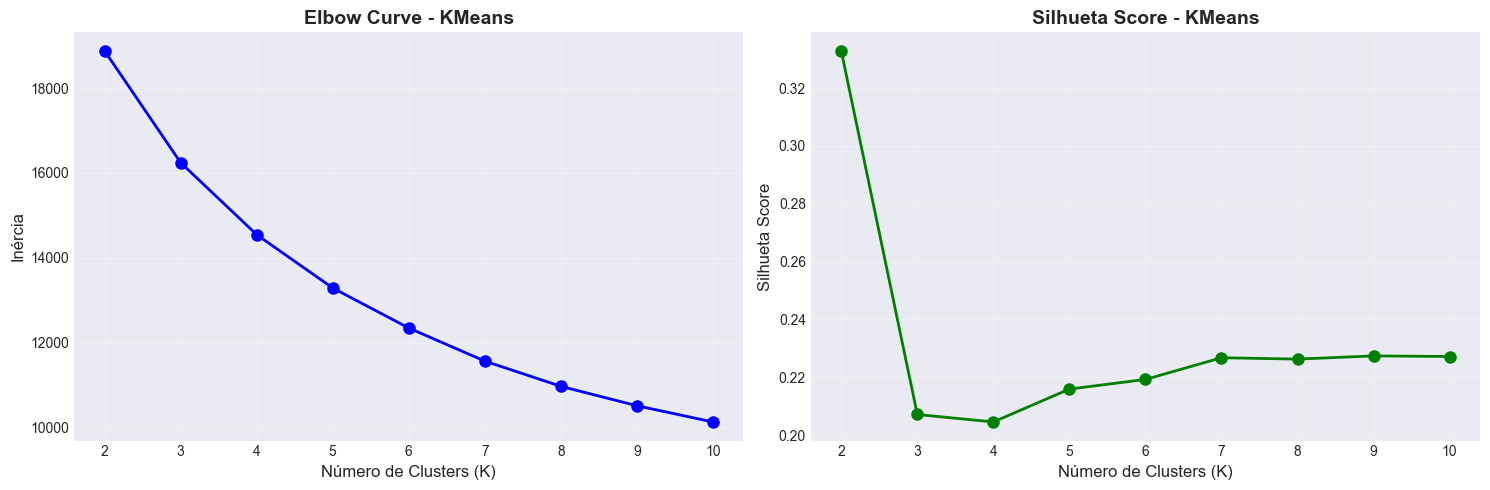

In [5]:

def gerar_elbow_curve(metricas_normalizadas, k_max=10):
    inercias = []
    silhuetas = []
    ks = range(2, k_max + 1)
    
    for k in ks:
        kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=500)
        kmeans_temp.fit(metricas_normalizadas)
        inercias.append(kmeans_temp.inertia_)
        score = silhouette_score(metricas_normalizadas, kmeans_temp.labels_)
        silhuetas.append(score)
        print(f"K={k}: Inércia={kmeans_temp.inertia_:.2f}, Silhueta={score:.4f}")
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    ax1.plot(ks, inercias, 'bo-', linewidth=2, markersize=8)
    ax1.set_xlabel('Número de Clusters (K)', fontsize=12)
    ax1.set_ylabel('Inércia', fontsize=12)
    ax1.set_title('Elbow Curve - KMeans', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(ks, silhuetas, 'go-', linewidth=2, markersize=8)
    ax2.set_xlabel('Número de Clusters (K)', fontsize=12)
    ax2.set_ylabel('Silhueta Score', fontsize=12)
    ax2.set_title('Silhueta Score - KMeans', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return inercias, silhuetas

print("Gerando Elbow Curve...")
inercias, silhuetas = gerar_elbow_curve(metricas_normalizadas, k_max=10)


In [6]:
def treinar_e_agrupar_alunos(df, cluster_metricas, metricas_normalizadas, n_clusters=4):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=20, max_iter=500, tol=1e-4)
    df['Grupo_ID'] = kmeans.fit_predict(metricas_normalizadas)
    
    ranking = df.groupby('Grupo_ID')['INDE_FINAL'].mean().sort_values().index.tolist()
    mapa_grupos = {idx: f"Nível {i+1}" for i, idx in enumerate(ranking)}
    df['Perfil_Nivel'] = df['Grupo_ID'].map(mapa_grupos)
    
    df['Alvo_PV'] = df['Atingiu PV'].apply(lambda x: 1 if str(x).strip().upper() == 'SIM' else 0)
    
    metricas = df[cluster_metricas]
    alvo = df['Alvo_PV']
    
    massa_treino, massa_teste, resposta_treino, resposta_teste = train_test_split(metricas, alvo, test_size=0.2, random_state=42)
    
    modelo_rf = RandomForestClassifier(n_estimators=150, min_samples_leaf=4, max_features='sqrt', random_state=42)
    modelo_rf.fit(massa_treino, resposta_treino)
    
    df['Probabilidade_PV'] = modelo_rf.predict_proba(metricas)[:, 1]
    
    return df, modelo_rf, kmeans, ranking


In [7]:
def visualizar_distribuicao_grupos(df, metricas_normalizadas, n_clusters):
    pca = PCA(n_components=2)
    metricas_2d = pca.fit_transform(metricas_normalizadas)
    
    plt.figure(figsize=(12, 8))
    
    grupos_unicos = sorted(df['Grupo_ID'].unique())
    cores = plt.cm.tab20(np.linspace(0, 1, n_clusters))
    
    for i, grupo in enumerate(grupos_unicos):
        mascara = df['Grupo_ID'] == grupo
        nivel = df[df['Grupo_ID']==grupo]['Perfil_Nivel'].iloc[0]
        plt.scatter(
            metricas_2d[mascara, 0],
            metricas_2d[mascara, 1],
            c=[cores[i]],
            label=f"{nivel} (Grupo {grupo})",
            s=100,
            alpha=0.6,
            edgecolors='black',
            linewidth=0.5
        )
    
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variância)', fontsize=11)
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variância)', fontsize=11)
    plt.title(f'Distribuição de Alunos por Grupo ({n_clusters} clusters)', fontsize=13, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


ANALISANDO K=3 CLUSTERS

--- Estatísticas por Grupo (K=3) ---
              Quantidade  INDE_Média  INDE_StdDev  Prob_PV_Média  Prob_PV_Min  \
Perfil_Nivel                                                                    
Nível 1                0        6.55         0.84           0.00          0.0   
Nível 2              601        7.56         0.23           0.05          0.0   
Nível 3              259        7.76         0.44           0.03          0.0   

              Prob_PV_Max  Atingiram_PV  
Perfil_Nivel                             
Nível 1              0.10             0  
Nível 2              0.53            70  
Nível 3              0.52            43  


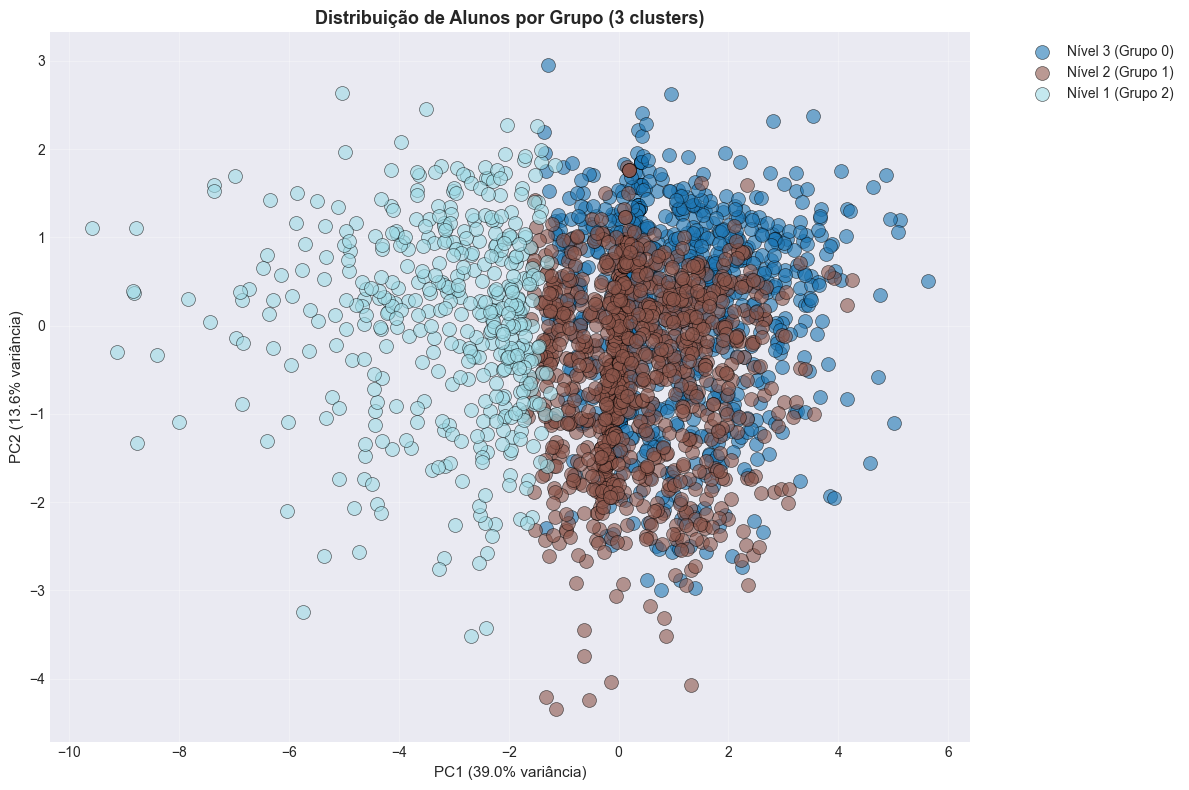

In [9]:
print("\n" + "="*60)
print("ANALISANDO K=3 CLUSTERS")
print("="*60)

df_k3 = df_final.copy()
df_k3, modelo_k3, kmeans_k3, ranking_k3 = treinar_e_agrupar_alunos(df_k3, cluster_metricas, metricas_normalizadas, n_clusters=3)

print("\n--- Estatísticas por Grupo (K=3) ---")
stats_k3 = df_k3.groupby('Perfil_Nivel').agg({
    'Nome': 'count',
    'INDE_FINAL': ['mean', 'std'],
    'Probabilidade_PV': ['mean', 'min', 'max'],
    'Alvo_PV': 'sum'
}).round(2)
stats_k3.columns = ['Quantidade', 'INDE_Média', 'INDE_StdDev', 'Prob_PV_Média', 'Prob_PV_Min', 'Prob_PV_Max', 'Atingiram_PV']
print(stats_k3)

visualizar_distribuicao_grupos(df_k3, metricas_normalizadas, 3)




ANALISANDO K=4 CLUSTERS

--- Estatísticas por Grupo (K=4) ---
              Quantidade  INDE_Média  INDE_StdDev  Prob_PV_Média  Prob_PV_Min  \
Perfil_Nivel                                                                    
Nível 1                0        6.31         0.83           0.00          0.0   
Nível 2              601        7.49         0.21           0.06          0.0   
Nível 3              259        7.60         0.23           0.04          0.0   
Nível 4                0        7.98         0.54           0.00          0.0   

              Prob_PV_Max  Atingiram_PV  
Perfil_Nivel                             
Nível 1              0.10             0  
Nível 2              0.53            70  
Nível 3              0.52            43  
Nível 4              0.15             0  


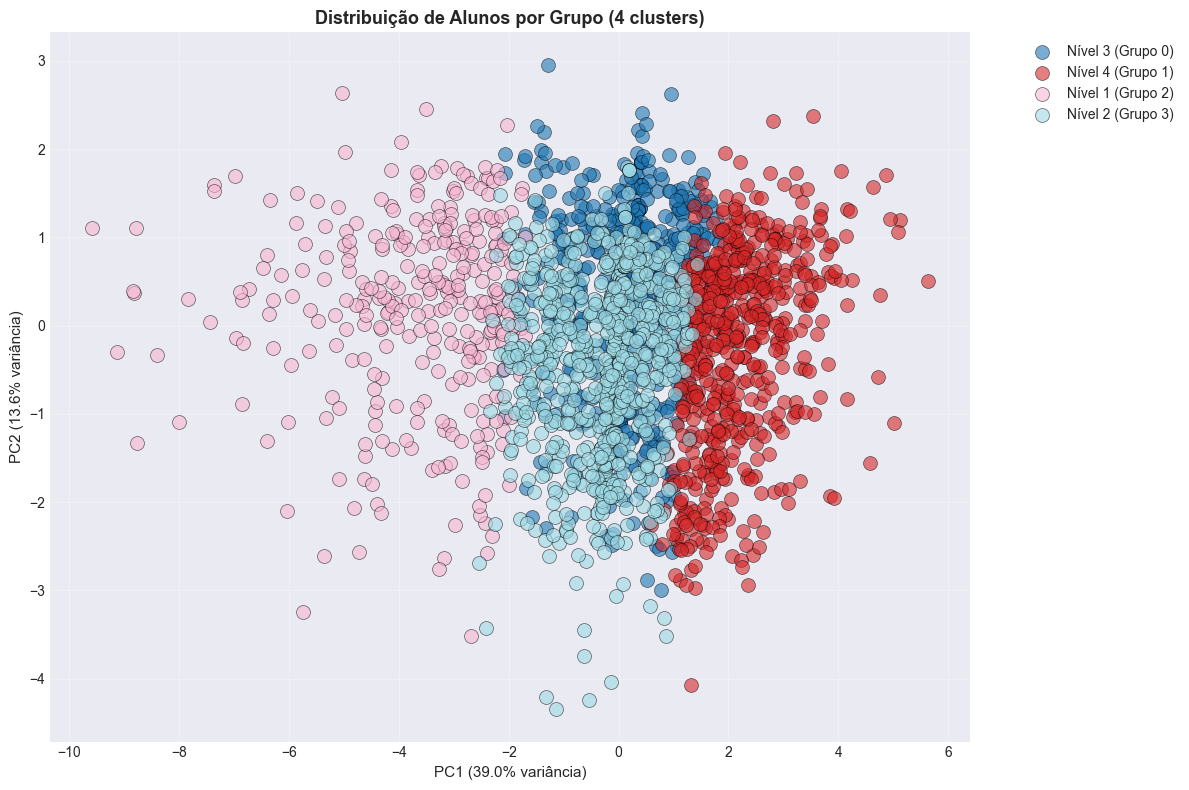

In [10]:

print("\n" + "="*60)
print("ANALISANDO K=4 CLUSTERS")
print("="*60)

df_k4 = df_final.copy()
df_k4, modelo_k4, kmeans_k4, ranking_k4 = treinar_e_agrupar_alunos(df_k4, cluster_metricas, metricas_normalizadas, n_clusters=4)

print("\n--- Estatísticas por Grupo (K=4) ---")
stats_k4 = df_k4.groupby('Perfil_Nivel').agg({
    'Nome': 'count',
    'INDE_FINAL': ['mean', 'std'],
    'Probabilidade_PV': ['mean', 'min', 'max'],
    'Alvo_PV': 'sum'
}).round(2)
stats_k4.columns = ['Quantidade', 'INDE_Média', 'INDE_StdDev', 'Prob_PV_Média', 'Prob_PV_Min', 'Prob_PV_Max', 'Atingiram_PV']
print(stats_k4)

visualizar_distribuicao_grupos(df_k4, metricas_normalizadas, 4)


ANALISANDO K=5 CLUSTERS

--- Estatísticas por Grupo (K=5) ---
              Quantidade  INDE_Média  INDE_StdDev  Prob_PV_Média  Prob_PV_Min  \
Perfil_Nivel                                                                    
Nível 1                0        6.30         0.83           0.00          0.0   
Nível 2              599        7.49         0.20           0.06          0.0   
Nível 3                8        7.53         0.19           0.00          0.0   
Nível 4              253        7.60         0.23           0.05          0.0   
Nível 5                0        8.14         0.55           0.00          0.0   

              Prob_PV_Max  Atingiram_PV  
Perfil_Nivel                             
Nível 1              0.10             0  
Nível 2              0.53            70  
Nível 3              0.13             2  
Nível 4              0.52            41  
Nível 5              0.15             0  


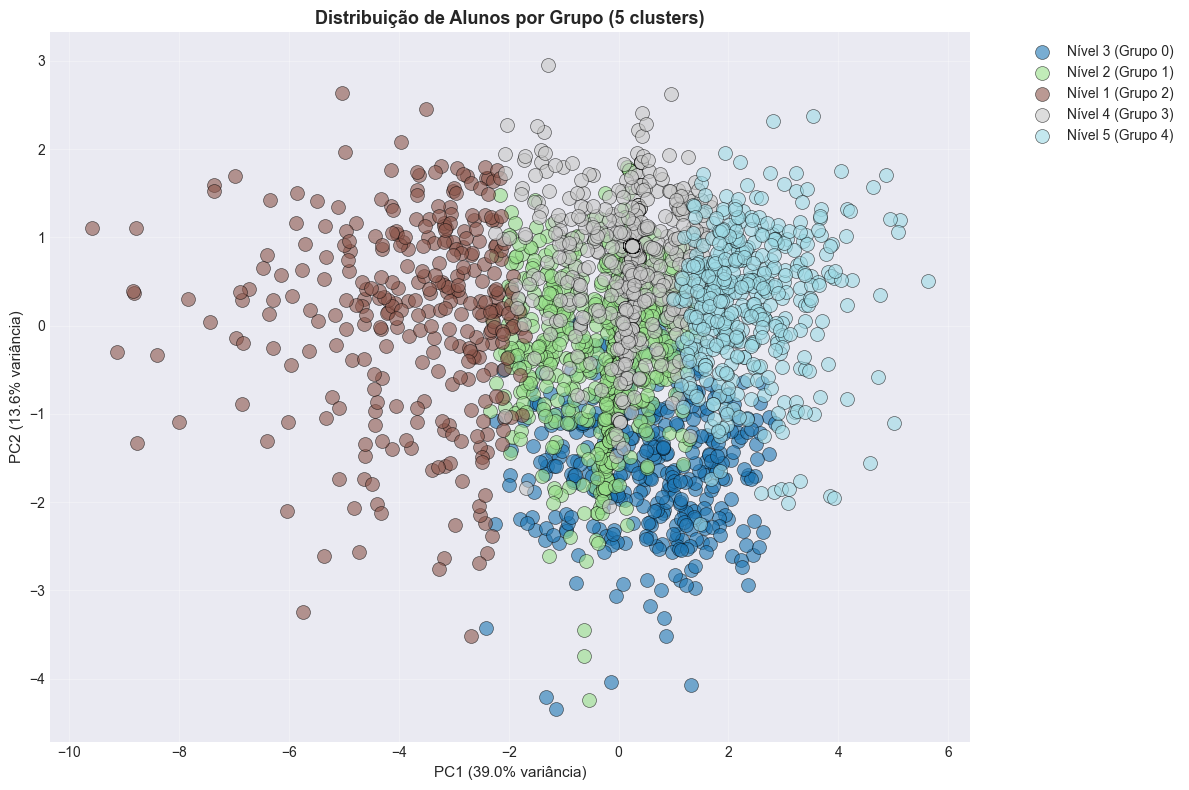

In [11]:
print("\n" + "="*60)
print("ANALISANDO K=5 CLUSTERS")
print("="*60)

df_k5 = df_final.copy()
df_k5, modelo_k5, kmeans_k5, ranking_k5 = treinar_e_agrupar_alunos(df_k5, cluster_metricas, metricas_normalizadas, n_clusters=5)

print("\n--- Estatísticas por Grupo (K=5) ---")
stats_k5 = df_k5.groupby('Perfil_Nivel').agg({
    'Nome': 'count',
    'INDE_FINAL': ['mean', 'std'],
    'Probabilidade_PV': ['mean', 'min', 'max'],
    'Alvo_PV': 'sum'
}).round(2)
stats_k5.columns = ['Quantidade', 'INDE_Média', 'INDE_StdDev', 'Prob_PV_Média', 'Prob_PV_Min', 'Prob_PV_Max', 'Atingiram_PV']
print(stats_k5)

visualizar_distribuicao_grupos(df_k5, metricas_normalizadas, 5)


In [12]:

print("\n" + "="*60)
print("COMPARAÇÃO DOS MODELOS")
print("="*60)

comparacao = pd.DataFrame({
    'K=3': [
        len(df_k3['Grupo_ID'].unique()),
        f"{df_k3['Alvo_PV'].sum()}/{len(df_k3)} ({df_k3['Alvo_PV'].sum()/len(df_k3)*100:.1f}%)"
    ],
    'K=4': [
        len(df_k4['Grupo_ID'].unique()),
        f"{df_k4['Alvo_PV'].sum()}/{len(df_k4)} ({df_k4['Alvo_PV'].sum()/len(df_k4)*100:.1f}%)"
    ],
    'K=5': [
        len(df_k5['Grupo_ID'].unique()),
        f"{df_k5['Alvo_PV'].sum()}/{len(df_k5)} ({df_k5['Alvo_PV'].sum()/len(df_k5)*100:.1f}%)"
    ]
}, index=['Clusters', 'Alunos que Atingiram PV'])

print(comparacao)


COMPARAÇÃO DOS MODELOS
                                     K=3              K=4              K=5
Clusters                               3                4                5
Alunos que Atingiram PV  113/3030 (3.7%)  113/3030 (3.7%)  113/3030 (3.7%)



TOP 10 ALUNOS COM MAIOR RISCO (K=4)
     Nome Perfil_Nivel  INDE_FINAL  Probabilidade_PV
2591  NaN      Nível 1    3.789478               0.0
2442  NaN      Nível 1    3.835478               0.0
2147  NaN      Nível 1    4.211814               0.0
2667  NaN      Nível 1    4.363946               0.0
2270  NaN      Nível 1    4.496081               0.0
2089  NaN      Nível 1    4.542230               0.0
2534  NaN      Nível 1    4.548545               0.0
2511  NaN      Nível 1    4.639154               0.0
1909  NaN      Nível 1    4.668435               0.0
2416  NaN      Nível 1    4.674365               0.0


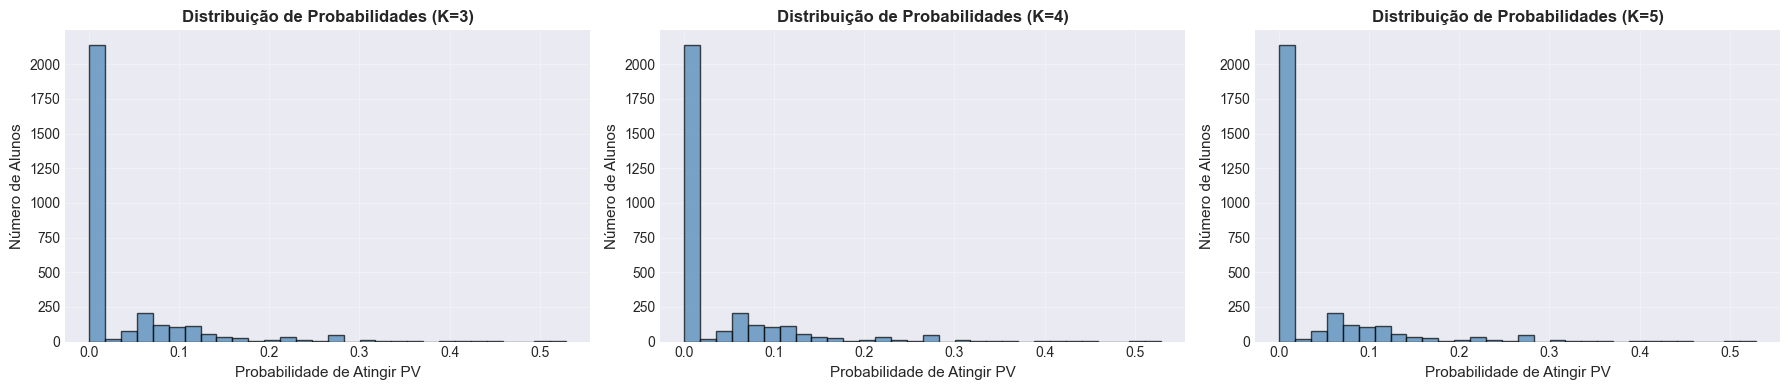

In [13]:
print("\n" + "="*60)
print("TOP 10 ALUNOS COM MAIOR RISCO (K=4)")
print("="*60)

alunos_risco = df_k4[df_k4['Alvo_PV'] == 0].sort_values(by=['Probabilidade_PV', 'INDE_FINAL']).head(10)
print(alunos_risco[['Nome', 'Perfil_Nivel', 'INDE_FINAL', 'Probabilidade_PV']].to_string())

# Célula 11: Distribuição de Probabilidades
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for idx, (df_temp, k) in enumerate([(df_k3, 3), (df_k4, 4), (df_k5, 5)]):
    axes[idx].hist(df_temp['Probabilidade_PV'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_xlabel('Probabilidade de Atingir PV', fontsize=11)
    axes[idx].set_ylabel('Número de Alunos', fontsize=11)
    axes[idx].set_title(f'Distribuição de Probabilidades (K={k})', fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
print("\n" + "="*60)
print("TOP 20 ALUNOS - RANKING INDIVIDUAL (K=4)")
print("="*60)

def rankear_alunos_individual(df, cluster_metricas):
    df_ranking = df.copy()
    metricas_numericas = [col for col in cluster_metricas if col in df.columns]
    df_ranking['Score_Individual'] = df_ranking[metricas_numericas].mean(axis=1)
    df_ranking['Ranking_Grupo'] = df_ranking.groupby('Grupo_ID')['Score_Individual'].rank(ascending=False).astype(int)
    df_ranking['Ranking_Geral'] = df_ranking['Score_Individual'].rank(ascending=False).astype(int)
    return df_ranking

ranking_k4 = rankear_alunos_individual(df_k4, cluster_metricas)
top_20 = ranking_k4.nlargest(20, 'Score_Individual')[['Nome', 'Perfil_Nivel', 'Score_Individual', 'Ranking_Geral', 'Probabilidade_PV']]
print(top_20.to_string())


TOP 20 ALUNOS - RANKING INDIVIDUAL (K=4)
     Nome Perfil_Nivel  Score_Individual  Ranking_Geral  Probabilidade_PV
2278  NaN      Nível 4          9.488644              1          0.014275
2900  NaN      Nível 4          9.422256              2          0.008349
2424  NaN      Nível 4          9.417017              3          0.000000
2449  NaN      Nível 4          9.413509              4          0.009608
2206  NaN      Nível 4          9.385572              5          0.000000
2531  NaN      Nível 4          9.357740              6          0.000000
2348  NaN      Nível 4          9.240634              7          0.012942
2896  NaN      Nível 4          9.210234              8          0.073685
2465  NaN      Nível 4          9.204006              9          0.000000
1991  NaN      Nível 4          9.193525             10          0.000000
2126  NaN      Nível 4          9.169879             11          0.000000
2425  NaN      Nível 4          9.101275             12          0.000

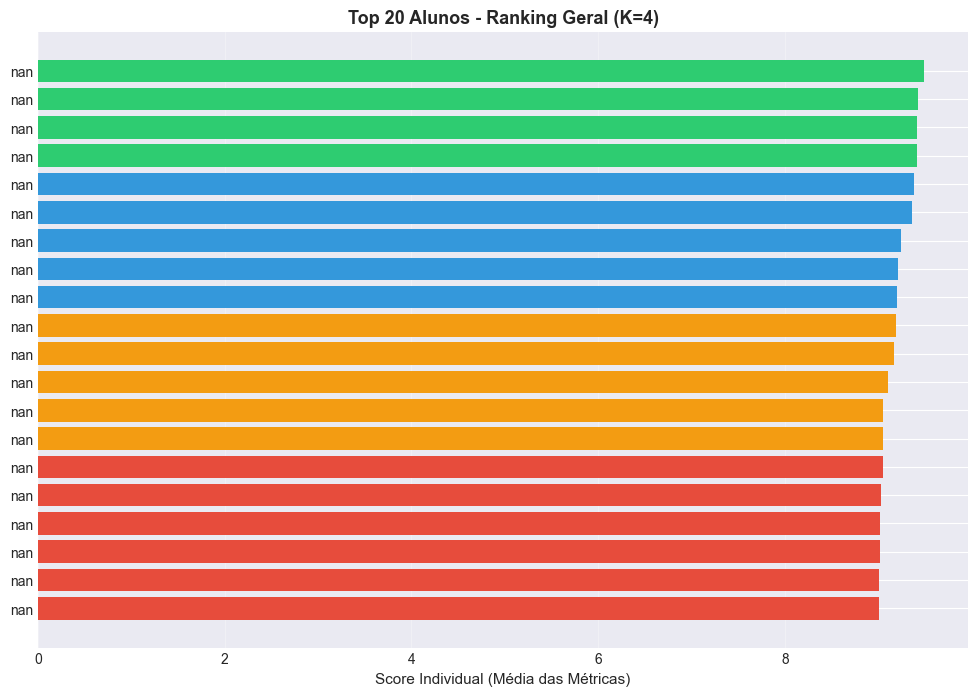

In [15]:
fig, ax = plt.subplots(figsize=(12, 8))
top_20_plot = top_20.reset_index(drop=True)
cores_ranking = ['#2ecc71' if x < 5 else '#3498db' if x < 10 else '#f39c12' if x < 15 else '#e74c3c' for x in top_20_plot['Ranking_Geral']]

ax.barh(range(len(top_20_plot)), top_20_plot['Score_Individual'], color=cores_ranking)
ax.set_yticks(range(len(top_20_plot)))
ax.set_yticklabels(top_20_plot['Nome'], fontsize=10)
ax.set_xlabel('Score Individual (Média das Métricas)', fontsize=11)
ax.set_title('Top 20 Alunos - Ranking Geral (K=4)', fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')